# Statistics for Data Science: The Complete Guide

## Why Statistics Matters in AI/ML
Every machine learning algorithm is grounded in statistics:
- **Linear Regression** → Ordinary Least Squares
- **Logistic Regression** → Maximum Likelihood Estimation
- **Naive Bayes** → Bayes' Theorem + Conditional Independence
- **Neural Networks** → Gradient descent, probabilistic outputs
- **Hypothesis Testing** → Evaluating model improvements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import gamma
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Libraries loaded')

Libraries loaded


## 1. Descriptive Statistics

### Measures of Central Tendency

**Mean (Arithmetic):**
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

**Weighted Mean:**
$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$$

**Geometric Mean** (for ratios/growth rates):
$$\bar{x}_g = \left(\prod_{i=1}^{n} x_i\right)^{1/n} = \exp\left(\frac{1}{n}\sum_{i=1}^{n} \ln x_i\right)$$

**Harmonic Mean** (for rates/speeds):
$$\bar{x}_h = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}$$

**Median:** Middle value when sorted. Robust to outliers.

**Mode:** Most frequent value.

In [2]:
data = np.array([2, 4, 4, 6, 8, 8, 8, 10, 12, 100])  # 100 is an outlier

print('=== Measures of Central Tendency ===')
print(f'Mean:           {np.mean(data):.2f}   ← pulled by outlier')
print(f'Median:         {np.median(data):.2f}   ← robust to outlier')
print(f'Mode:           {stats.mode(data, keepdims=True).mode[0]:.2f}')
print(f'Geometric Mean: {stats.gmean(data):.2f}')
print(f'Harmonic Mean:  {stats.hmean(data):.2f}')
print(f'Trimmed Mean (10%): {stats.trim_mean(data, 0.1):.2f}  ← trims top/bottom 10%')

=== Measures of Central Tendency ===
Mean:           16.20   ← pulled by outlier
Median:         8.00   ← robust to outlier
Mode:           8.00
Geometric Mean: 8.08
Harmonic Mean:  5.76
Trimmed Mean (10%): 7.50  ← trims top/bottom 10%


### Measures of Dispersion

**Variance** (population and sample):
$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2 \quad \text{(population)}$$
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2 \quad \text{(sample, Bessel's correction)}$$

**Standard Deviation:**
$$\sigma = \sqrt{\sigma^2}, \quad s = \sqrt{s^2}$$

**Coefficient of Variation (CV)** normalized spread:
$$CV = \frac{s}{\bar{x}} \times 100\%$$

**Skewness** asymmetry of distribution:
$$\text{Skewness} = \frac{\frac{1}{n}\sum(x_i-\bar{x})^3}{s^3}$$
- Skewness > 0: right-skewed (tail on right)
- Skewness < 0: left-skewed (tail on left)

**Kurtosis** tailedness:
$$\text{Kurtosis} = \frac{\frac{1}{n}\sum(x_i-\bar{x})^4}{s^4} - 3$$
- Excess kurtosis > 0: leptokurtic (heavy tails)
- Excess kurtosis < 0: platykurtic (light tails)
- Normal distribution: excess kurtosis = 0

In [3]:
data_normal = np.random.normal(50, 10, 1000)
data_skewed = np.random.exponential(10, 1000)

print('=== Normal Distribution ===')
print(f'Variance:  {np.var(data_normal, ddof=1):.2f}')
print(f'Std Dev:   {np.std(data_normal, ddof=1):.2f}')
print(f'CV:        {np.std(data_normal)/np.mean(data_normal)*100:.2f}%')
print(f'Skewness:  {stats.skew(data_normal):.4f} (close to 0 symmetric)')
print(f'Kurtosis:  {stats.kurtosis(data_normal):.4f} (close to 0 normal tails)')

print('\n=== Skewed Distribution (Exponential) ===')
print(f'Skewness:  {stats.skew(data_skewed):.4f} (positive right-skewed)')
print(f'Kurtosis:  {stats.kurtosis(data_skewed):.4f} (positive heavy tails)')

# IQR and outliers
q1, q3 = np.percentile(data_normal, [25, 75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = data_normal[(data_normal < lower_fence) | (data_normal > upper_fence)]
print(f'\nIQR: {iqr:.2f}')
print(f'Outlier fences: [{lower_fence:.2f}, {upper_fence:.2f}]')
print(f'Outliers (Tukey): {len(outliers)} ({len(outliers)/len(data_normal)*100:.1f}%)')

=== Normal Distribution ===
Variance:  95.89
Std Dev:   9.79
CV:        19.50%
Skewness:  0.1168 (close to 0 symmetric)
Kurtosis:  0.0662 (close to 0 normal tails)

=== Skewed Distribution (Exponential) ===
Skewness:  1.9808 (positive right-skewed)
Kurtosis:  5.3794 (positive heavy tails)

IQR: 12.96
Outlier fences: [24.09, 75.91]
Outliers (Tukey): 8 (0.8%)


## 2. Probability Distributions

### 2.1 Normal (Gaussian) Distribution

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- Parameters: $\mu$ (mean), $\sigma^2$ (variance)
- **68-95-99.7 Rule**: 68% within 1σ, 95% within 2σ, 99.7% within 3σ
- Standard Normal: $Z = \frac{X - \mu}{\sigma} \sim \mathcal{N}(0,1)$

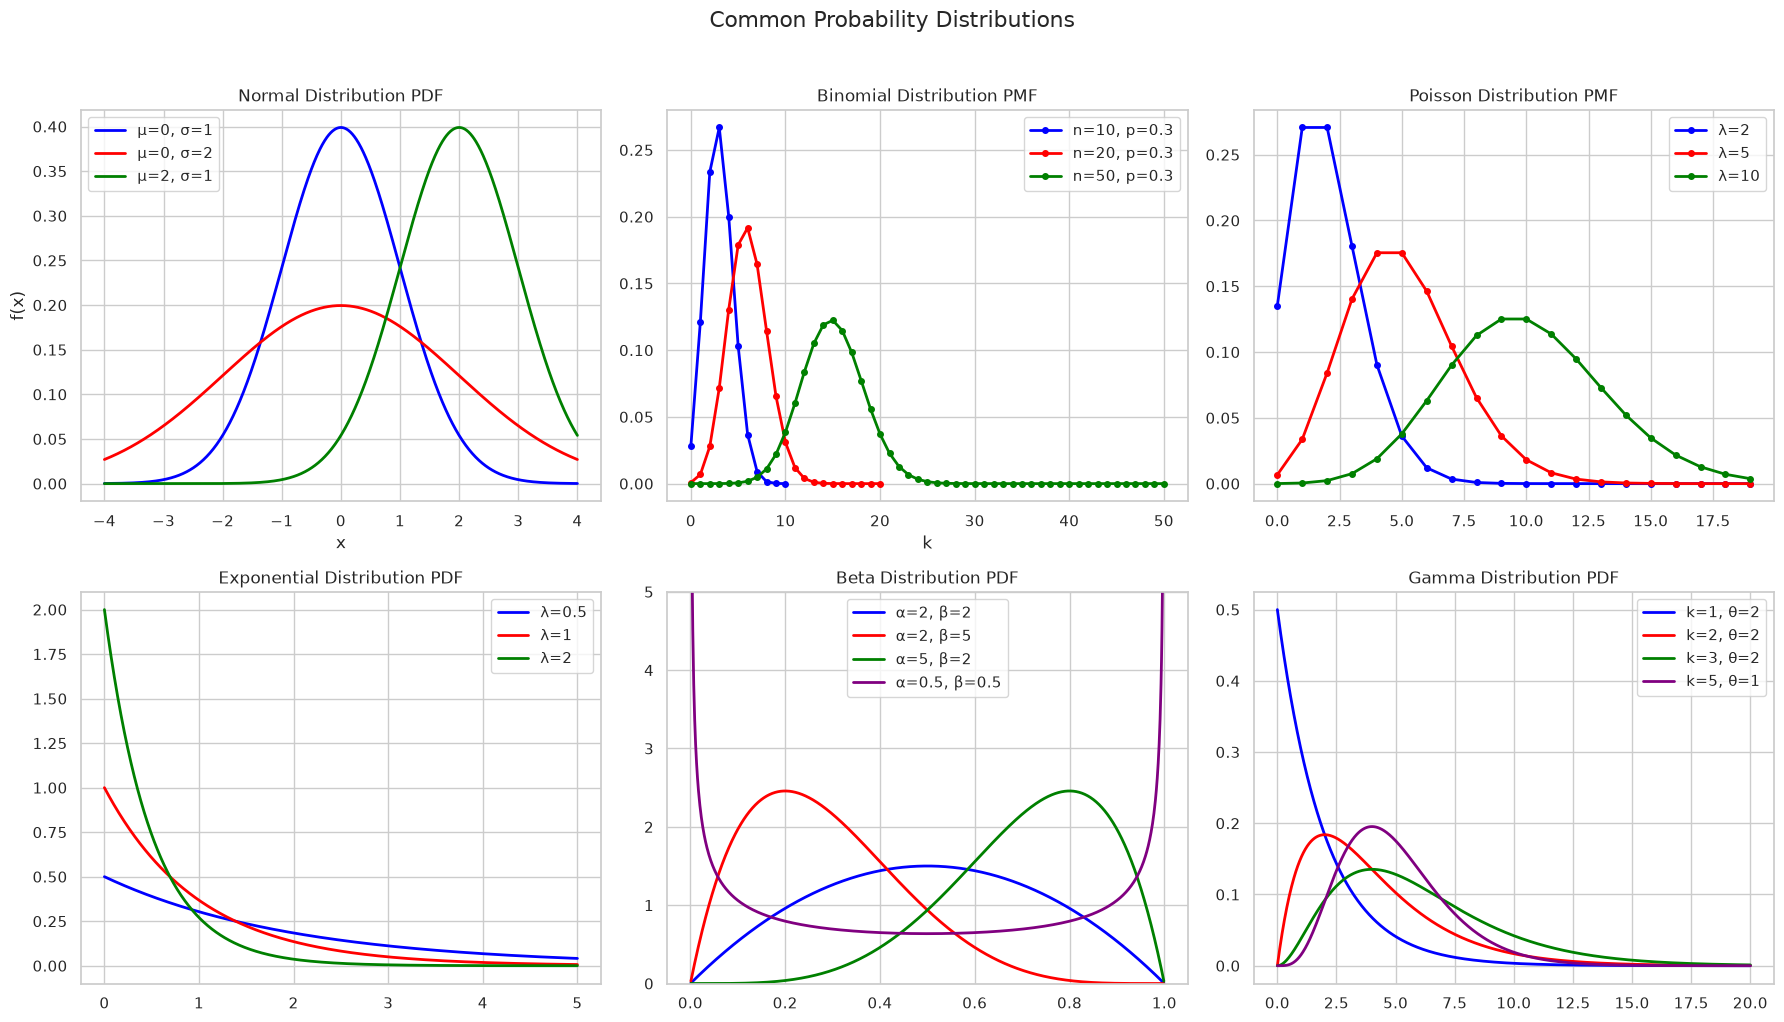

In [4]:
x = np.linspace(-4, 4, 1000)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Normal distribution
for mu, sigma, color in [(0,1,'blue'), (0,2,'red'), (2,1,'green')]:
    axes[0,0].plot(x, stats.norm.pdf(x, mu, sigma),
                   label=f'μ={mu}, σ={sigma}', color=color, linewidth=2)
axes[0,0].set_title('Normal Distribution PDF')
axes[0,0].legend()
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('f(x)')

# Binomial distribution
# PMF: P(X=k) = C(n,k) * p^k * (1-p)^(n-k)
n_vals = [10, 20, 50]
p = 0.3
for n_b, color in zip(n_vals, ['blue','red','green']):
    k = np.arange(0, n_b+1)
    axes[0,1].plot(k, stats.binom.pmf(k, n_b, p), 'o-', color=color,
                   label=f'n={n_b}, p={p}', linewidth=2, markersize=4)
axes[0,1].set_title('Binomial Distribution PMF')
axes[0,1].legend()
axes[0,1].set_xlabel('k')

# Poisson distribution
# PMF: P(X=k) = (lambda^k * e^(-lambda)) / k!
k_pois = np.arange(0, 20)
for lam, color in [(2,'blue'),(5,'red'),(10,'green')]:
    axes[0,2].plot(k_pois, stats.poisson.pmf(k_pois, lam), 'o-', color=color,
                   label=f'λ={lam}', linewidth=2, markersize=4)
axes[0,2].set_title('Poisson Distribution PMF')
axes[0,2].legend()

# Exponential distribution
# PDF: f(x) = lambda * e^(-lambda*x)
x_exp = np.linspace(0, 5, 1000)
for lam, color in [(0.5,'blue'),(1,'red'),(2,'green')]:
    axes[1,0].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam),
                   color=color, label=f'λ={lam}', linewidth=2)
axes[1,0].set_title('Exponential Distribution PDF')
axes[1,0].legend()

# Beta distribution
# PDF: f(x; a, b) = x^(a-1)*(1-x)^(b-1) / B(a,b), x in [0,1]
x_beta = np.linspace(0.001, 0.999, 1000)
for a, b, color in [(2,2,'blue'),(2,5,'red'),(5,2,'green'),(0.5,0.5,'purple')]:
    axes[1,1].plot(x_beta, stats.beta.pdf(x_beta, a, b),
                   color=color, label=f'α={a}, β={b}', linewidth=2)
axes[1,1].set_title('Beta Distribution PDF')
axes[1,1].legend()
axes[1,1].set_ylim(0, 5)

# Gamma distribution
# PDF: f(x; k, θ) = x^(k-1)*e^(-x/θ) / (θ^k * Γ(k))
x_gamma = np.linspace(0, 20, 1000)
for k, theta, color in [(1,2,'blue'),(2,2,'red'),(3,2,'green'),(5,1,'purple')]:
    axes[1,2].plot(x_gamma, stats.gamma.pdf(x_gamma, k, scale=theta),
                   color=color, label=f'k={k}, θ={theta}', linewidth=2)
axes[1,2].set_title('Gamma Distribution PDF')
axes[1,2].legend()

plt.suptitle('Common Probability Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hypothesis Testing

### Framework
1. State **H₀** (null hypothesis) and **H₁** (alternative hypothesis)
2. Choose **significance level** α (usually 0.05)
3. Compute **test statistic**
4. Compute **p-value** = P(observing data at least as extreme | H₀ is true)
5. If p-value < α → **Reject H₀**

### Type I and Type II Errors
| | H₀ True | H₀ False |
|---|---------|----------|
| **Reject H₀** | Type I Error (α) | Correct (Power = 1-β) |
| **Don't Reject H₀** | Correct (1-α) | Type II Error (β) |

### One-Sample t-test
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$
degrees of freedom: $df = n - 1$

### Two-Sample t-test (Welch's)
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

In [5]:
# One-sample t-test
# H0: population mean = 100, H1: mean ≠ 100
sample = np.random.normal(102, 15, 50)
t_stat, p_value = stats.ttest_1samp(sample, popmean=100)
print('=== One-Sample t-test ===')
print(f'H0: μ = 100')
print(f'Sample mean: {sample.mean():.2f}, n={len(sample)}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Result: {"Reject H0" if p_value < 0.05 else "Fail to Reject H0"} at α=0.05')

# Two-sample t-test
group_a = np.random.normal(50, 10, 40)
group_b = np.random.normal(55, 12, 45)
t_stat2, p_value2 = stats.ttest_ind(group_a, group_b, equal_var=False)  # Welch's
print('\n=== Two-Sample t-test (Welch) ===')
print(f'Group A: mean={group_a.mean():.2f}, Group B: mean={group_b.mean():.2f}')
print(f't-statistic: {t_stat2:.4f}')
print(f'p-value: {p_value2:.4f}')
print(f'Result: {"Reject H0" if p_value2 < 0.05 else "Fail to Reject H0"} at α=0.05')

# Paired t-test
before = np.random.normal(70, 10, 30)
after = before + np.random.normal(5, 5, 30)  # treatment effect
t_stat3, p_value3 = stats.ttest_rel(before, after)
print('\n=== Paired t-test ===')
print(f'Before: {before.mean():.2f}, After: {after.mean():.2f}')
print(f'p-value: {p_value3:.4f}')
print(f'Result: {"Reject H0" if p_value3 < 0.05 else "Fail to Reject H0"} at α=0.05')

=== One-Sample t-test ===
H0: μ = 100
Sample mean: 100.17, n=50
t-statistic: 0.0894
p-value: 0.9291
Result: Fail to Reject H0 at α=0.05

=== Two-Sample t-test (Welch) ===
Group A: mean=50.48, Group B: mean=53.73
t-statistic: -1.4272
p-value: 0.1573
Result: Fail to Reject H0 at α=0.05

=== Paired t-test ===
Before: 70.93, After: 76.64
p-value: 0.0000
Result: Reject H0 at α=0.05


### Chi-Square Test

Tests independence between two categorical variables.

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

where $E_{ij} = \frac{\text{row total}_i \times \text{col total}_j}{N}$, $df = (r-1)(c-1)$

In [6]:
# Chi-square test of independence
# Observed: Gender vs Preference
observed = np.array([
    [30, 20, 10],  # Male: Cat A, Cat B, Cat C
    [15, 35, 20]   # Female: Cat A, Cat B, Cat C
])

chi2, p_chi, dof, expected = stats.chi2_contingency(observed)
print('=== Chi-Square Test of Independence ===')
print(f'Observed:\n{observed}')
print(f'Expected:\n{expected.round(2)}')
print(f'Chi2 = {chi2:.4f}, df = {dof}, p-value = {p_chi:.4f}')
print(f'Result: {"Reject H0 (dependent)" if p_chi < 0.05 else "Fail to Reject H0 (independent)"}')

# Chi-square goodness of fit
observed_gof = [30, 25, 20, 15, 10]
expected_gof = [20, 20, 20, 20, 20]  # uniform
chi2_gof, p_gof = stats.chisquare(observed_gof, expected_gof)
print(f'\nGoodness of Fit: chi2={chi2_gof:.4f}, p={p_gof:.4f}')
print(f'Data fits uniform? {"No" if p_gof < 0.05 else "Yes"}')

=== Chi-Square Test of Independence ===
Observed:
[[30 20 10]
 [15 35 20]]
Expected:
[[20.77 25.38 13.85]
 [24.23 29.62 16.15]]
Chi2 = 11.7244, df = 2, p-value = 0.0028
Result: Reject H0 (dependent)

Goodness of Fit: chi2=12.5000, p=0.0140
Data fits uniform? No


### ANOVA (Analysis of Variance)

Tests equality of means across 3+ groups.

$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}} = \frac{MS_B}{MS_W}$$

$$SS_B = \sum_{j=1}^{k} n_j(\bar{x}_j - \bar{x})^2, \quad SS_W = \sum_{j=1}^{k}\sum_{i=1}^{n_j}(x_{ij} - \bar{x}_j)^2$$

In [7]:
# One-Way ANOVA
group1 = np.random.normal(50, 10, 30)
group2 = np.random.normal(55, 10, 30)
group3 = np.random.normal(60, 10, 30)
group4 = np.random.normal(52, 10, 30)

f_stat, p_anova = stats.f_oneway(group1, group2, group3, group4)
print('=== One-Way ANOVA ===')
print(f'Means: G1={group1.mean():.2f}, G2={group2.mean():.2f}, G3={group3.mean():.2f}, G4={group4.mean():.2f}')
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_anova:.4f}')
print(f'Result: {"Reject H0 (groups differ)" if p_anova < 0.05 else "Fail to Reject H0"}')

# Post-hoc test (Tukey's HSD) to find which groups differ
from scipy.stats import tukey_hsd
result = tukey_hsd(group1, group2, group3, group4)
print('\nTukey HSD pairwise p-values:')
for i, j in [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]:
    p = result.pvalue[i][j]
    print(f'  Group {i+1} vs Group {j+1}: p={p:.4f} {"*" if p < 0.05 else ""}')

=== One-Way ANOVA ===
Means: G1=49.99, G2=54.21, G3=59.48, G4=51.19
F-statistic: 5.9374
p-value: 0.0008
Result: Reject H0 (groups differ)

Tukey HSD pairwise p-values:
  Group 1 vs Group 2: p=0.3198 
  Group 1 vs Group 3: p=0.0011 *
  Group 1 vs Group 4: p=0.9621 
  Group 2 vs Group 3: p=0.1448 
  Group 2 vs Group 4: p=0.6088 
  Group 3 vs Group 4: p=0.0054 *


## 4. Central Limit Theorem

$$\bar{X}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

**Regardless of the population distribution**, the sampling distribution of the sample mean approaches a normal distribution as $n$ increases.

**Standard Error:** $SE = \frac{\sigma}{\sqrt{n}}$

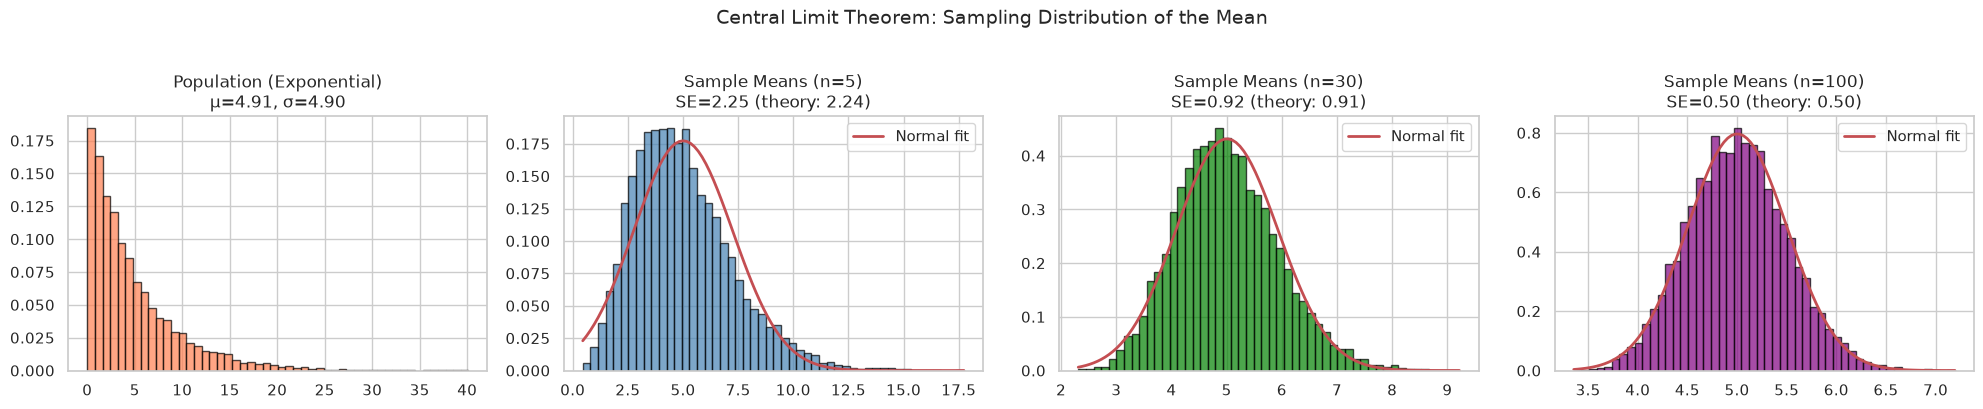

In [8]:
# CLT Demonstration
pop_distribution = stats.expon(scale=5)  # Skewed population!
n_samples = 10000

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Population
pop_data = pop_distribution.rvs(n_samples)
axes[0].hist(pop_data, bins=50, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[0].set_title(f'Population (Exponential)\nμ={pop_data.mean():.2f}, σ={pop_data.std():.2f}')

# Sampling distributions for different n
for ax, n, color in zip(axes[1:], [5, 30, 100], ['steelblue', 'green', 'purple']):
    sample_means = [pop_distribution.rvs(n).mean() for _ in range(n_samples)]
    ax.hist(sample_means, bins=50, color=color, edgecolor='black', alpha=0.7, density=True)
    theoretical_se = pop_distribution.std() / np.sqrt(n)
    x_norm = np.linspace(min(sample_means), max(sample_means), 100)
    ax.plot(x_norm, stats.norm.pdf(x_norm, np.mean(sample_means), np.std(sample_means)),
            'r-', linewidth=2, label='Normal fit')
    ax.set_title(f'Sample Means (n={n})\nSE={np.std(sample_means):.2f} (theory: {theoretical_se:.2f})')
    ax.legend()

plt.suptitle('Central Limit Theorem: Sampling Distribution of the Mean', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/clt.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bayes' Theorem

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In ML terms:
$$P(\theta | \text{data}) = \frac{P(\text{data} | \theta) \cdot P(\theta)}{P(\text{data})}$$

- $P(\theta)$ = **Prior** what we believed before seeing data
- $P(\text{data}|\theta)$ = **Likelihood** probability of data given parameters
- $P(\theta|\text{data})$ = **Posterior** updated belief after seeing data
- $P(\text{data})$ = **Evidence** (normalizing constant)

In [9]:
# Medical test example
# Disease prevalence: 1%
# Test sensitivity (True Positive Rate): 99%
# Test specificity (True Negative Rate): 95%

p_disease = 0.01          # P(D)
p_no_disease = 1 - p_disease  # P(~D)
sensitivity = 0.99        # P(+|D)
specificity = 0.95        # P(-|~D)
p_pos_given_no_disease = 1 - specificity  # P(+|~D) = false positive rate

# P(+) = P(+|D)*P(D) + P(+|~D)*P(~D)
p_positive = sensitivity * p_disease + p_pos_given_no_disease * p_no_disease

# P(D|+) by Bayes' theorem
p_disease_given_positive = (sensitivity * p_disease) / p_positive

print('=== Bayesian Medical Diagnosis ===')
print(f'Disease prevalence: {p_disease*100:.1f}%')
print(f'Test Sensitivity: {sensitivity*100:.1f}%')
print(f'Test Specificity: {specificity*100:.1f}%')
print(f'\nP(positive test): {p_positive*100:.2f}%')
print(f'P(disease | positive test) = {p_disease_given_positive*100:.2f}%')
print('\n→ Even with a 99% sensitive test, a positive result only means')
print(f'  ~{p_disease_given_positive*100:.0f}% chance of disease due to low prevalence!')

=== Bayesian Medical Diagnosis ===
Disease prevalence: 1.0%
Test Sensitivity: 99.0%
Test Specificity: 95.0%

P(positive test): 5.94%
P(disease | positive test) = 16.67%

→ Even with a 99% sensitive test, a positive result only means
  ~17% chance of disease due to low prevalence!


## 6. MLE and MAP Estimation

### Maximum Likelihood Estimation (MLE)

Find parameters $\theta$ that maximize the likelihood of observing the data:

$$\hat{\theta}_{MLE} = \arg\max_\theta \mathcal{L}(\theta; X) = \arg\max_\theta \prod_{i=1}^{n} p(x_i | \theta)$$

In practice, maximize the **log-likelihood** (sum instead of product):

$$\hat{\theta}_{MLE} = \arg\max_\theta \sum_{i=1}^{n} \log p(x_i | \theta)$$

### Maximum A Posteriori (MAP)

MLE + prior:

$$\hat{\theta}_{MAP} = \arg\max_\theta \left[\sum_{i=1}^n \log p(x_i|\theta) + \log p(\theta)\right]$$

**MLE for Gaussian** the MLE estimate for mean is just the sample mean:
$$\hat{\mu} = \frac{1}{n}\sum x_i, \quad \hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \hat{\mu})^2$$

True p: 0.7, MLE estimate: 0.670


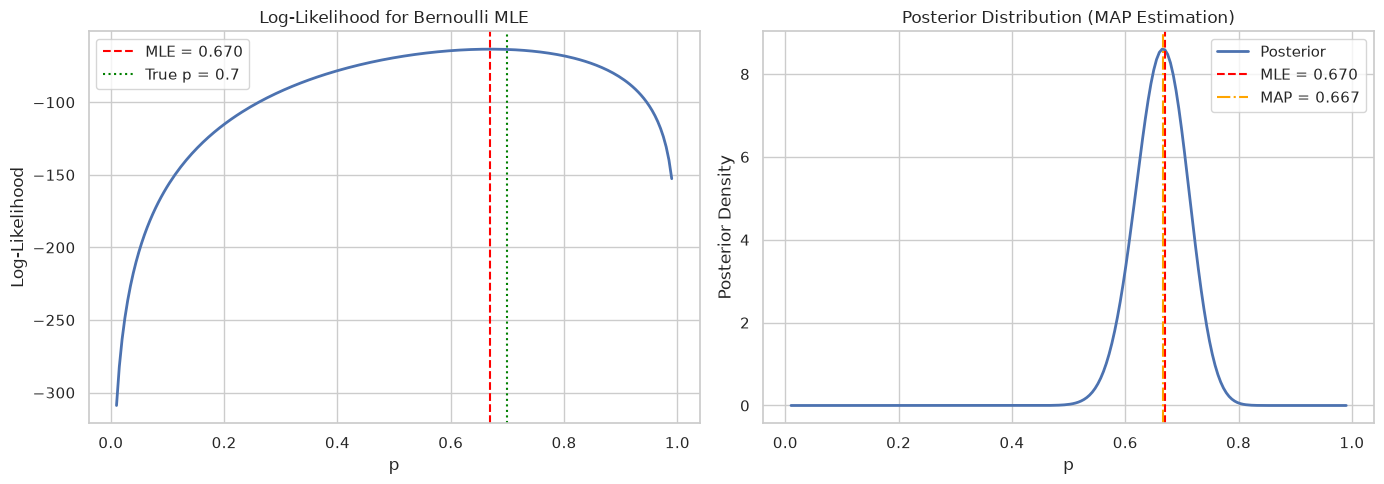


MLE: 0.6700, MAP: 0.6667, True: 0.7


In [10]:
# MLE for Bernoulli (coin flips)
# Likelihood: L(p) = p^k * (1-p)^(n-k)
# Log-likelihood: l(p) = k*log(p) + (n-k)*log(1-p)
# MLE: p_hat = k/n

n_flips = 100
true_p = 0.7
flips = np.random.binomial(1, true_p, n_flips)
p_hat_mle = flips.mean()
print(f'True p: {true_p}, MLE estimate: {p_hat_mle:.3f}')

# Visualize log-likelihood
p_range = np.linspace(0.01, 0.99, 200)
k = flips.sum()
log_likelihood = k * np.log(p_range) + (n_flips - k) * np.log(1 - p_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p_range, log_likelihood, 'b-', linewidth=2)
axes[0].axvline(x=p_hat_mle, color='red', linestyle='--', label=f'MLE = {p_hat_mle:.3f}')
axes[0].axvline(x=true_p, color='green', linestyle=':', label=f'True p = {true_p}')
axes[0].set_title('Log-Likelihood for Bernoulli MLE')
axes[0].set_xlabel('p')
axes[0].set_ylabel('Log-Likelihood')
axes[0].legend()

# MAP vs MLE (with Beta prior)
# Prior: Beta(2, 2) mild prior toward 0.5
alpha_prior, beta_prior = 2, 2
# Posterior: Beta(k + alpha, n-k + beta)
alpha_post = k + alpha_prior
beta_post = n_flips - k + beta_prior
p_hat_map = (alpha_post - 1) / (alpha_post + beta_post - 2)

posterior = stats.beta(alpha_post, beta_post)
axes[1].plot(p_range, posterior.pdf(p_range), 'b-', linewidth=2, label='Posterior')
axes[1].axvline(x=p_hat_mle, color='red', linestyle='--', label=f'MLE = {p_hat_mle:.3f}')
axes[1].axvline(x=p_hat_map, color='orange', linestyle='-.',
                label=f'MAP = {p_hat_map:.3f}')
axes[1].set_title('Posterior Distribution (MAP Estimation)')
axes[1].set_xlabel('p')
axes[1].set_ylabel('Posterior Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/mle_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nMLE: {p_hat_mle:.4f}, MAP: {p_hat_map:.4f}, True: {true_p}')

## 7. Confidence Intervals

A **95% confidence interval** means: if we repeated the experiment 100 times, ~95 of the intervals would contain the true parameter.

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}} \quad \text{(known } \sigma \text{)}$$
$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}} \quad \text{(unknown } \sigma \text{)}$$

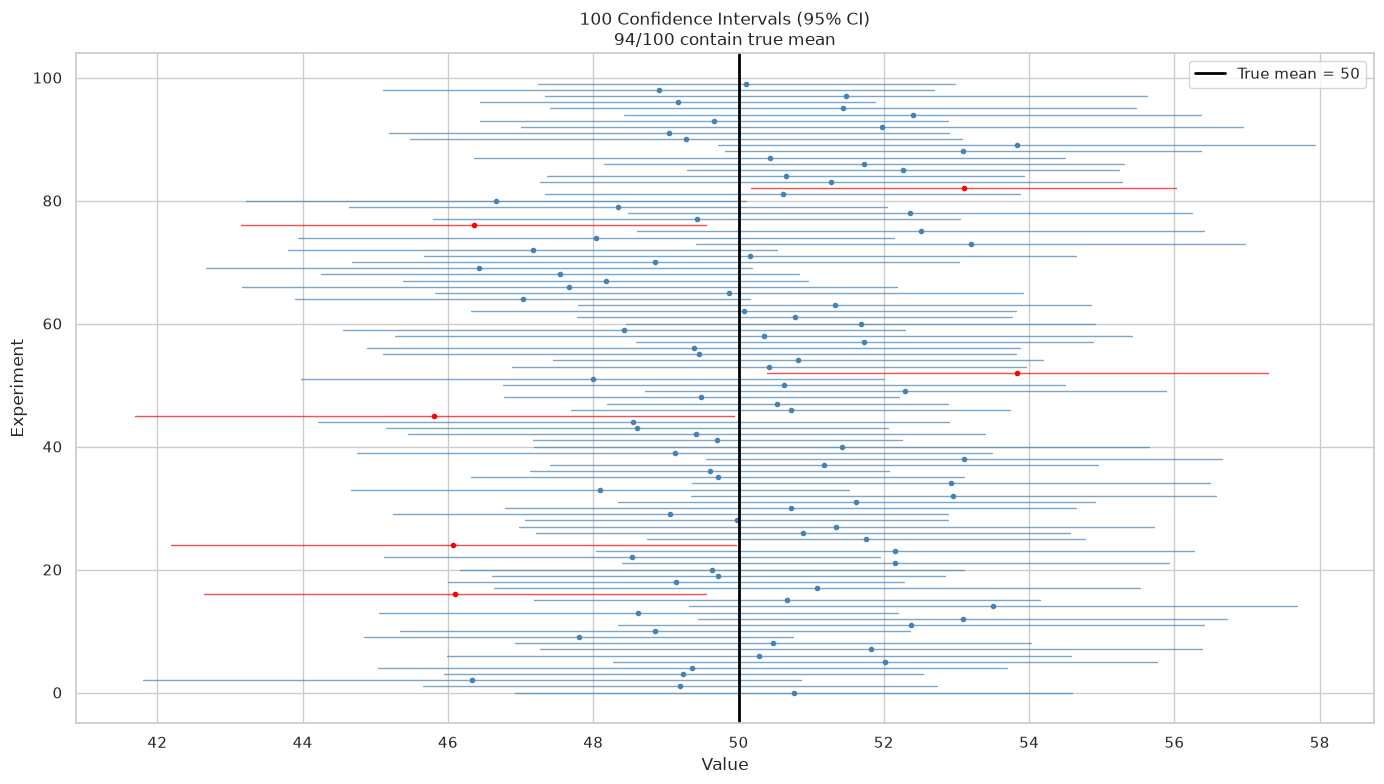

Coverage: 94/100 = 94%


In [11]:
# Confidence interval demonstration
true_mean = 50
true_std = 10
n = 30
n_experiments = 100

contains_true = 0
fig, ax = plt.subplots(figsize=(14, 8))

for i in range(n_experiments):
    sample = np.random.normal(true_mean, true_std, n)
    ci = stats.t.interval(0.95, df=n-1, loc=sample.mean(), scale=stats.sem(sample))
    contains = ci[0] <= true_mean <= ci[1]
    contains_true += contains
    color = 'steelblue' if contains else 'red'
    ax.plot([ci[0], ci[1]], [i, i], color=color, linewidth=1, alpha=0.7)
    ax.plot(sample.mean(), i, 'o', color=color, markersize=3)

ax.axvline(x=true_mean, color='black', linewidth=2, label=f'True mean = {true_mean}')
ax.set_title(f'100 Confidence Intervals (95% CI)\n{contains_true}/100 contain true mean')
ax.set_xlabel('Value')
ax.set_ylabel('Experiment')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Coverage: {contains_true}/{n_experiments} = {contains_true}%')

## Additional Learning Resources

### Free Books
- **Think Stats** Allen Downey: https://greenteapress.com/wp/think-stats-2e/
- **Think Bayes** Allen Downey: https://greenteapress.com/wp/think-bayes/
- **Introduction to Statistical Learning** James et al.: https://www.statlearning.com/
- **The Elements of Statistical Learning** Hastie et al.: https://web.stanford.edu/~hastie/ElemStatLearn/

### Video Courses
- **StatQuest with Josh Starmer**: https://www.youtube.com/@statquest
- **Khan Academy Statistics**: https://www.khanacademy.org/math/statistics-probability
- **MIT 18.650 Statistics for Applications**: https://ocw.mit.edu/courses/18-650-statistics-for-applications-fall-2016/

### Papers
- **Original Hypothesis Testing (Neyman & Pearson, 1933)**: https://royalsocietypublishing.org/doi/10.1098/rsta.1933.0009
- **Wald, Abraham Sequential Analysis (1947)**
- **Box & Tiao Bayesian Inference in Statistical Analysis**

### Interactive Tools
- **Seeing Theory (Brown Univ.)**: https://seeing-theory.brown.edu/
- **Probability Distributions Interactive**: https://distribution-explorer.github.io/